# Mental Health Score Prediction - EDA & Model Training

Educational ML project. Predicts a continuous wellbeing score (0-100) from lifestyle/behavioral survey-style features.

> **Disclaimer:** Not a medical or diagnostic tool. Predictions are estimates for educational purposes only.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys, os
sys.path.append(os.path.join(os.getcwd(), '..', 'src'))
sns.set_style('whitegrid')

df = pd.read_csv('../data/dataset.csv')
df.head()

,Age,Gender,Employment_Status,Sleep_Hours,Sleep_Quality,Screen_Time_Hours,Physical_Activity_Hours,Social_Interaction_Score,Diet_Quality,Caffeine_Intake_Cups,Work_Study_Hours,Academic_Work_Pressure,Financial_Stress,Family_Support_Score,Stress_Level,Mental_Health_Score
0,59,Male,Employed,6.3,7.1,4.1,0.1,7.1,2.3,1,6.7,8.7,3.5,3.6,7.6,45.1
1,21,Female,Employed,6.4,8.5,6.2,2.2,7.0,4.6,2,10.5,4.5,5.5,5.5,6.3,62.8
2,56,Male,Employed,5.0,5.2,7.5,0.2,7.5,10.0,6,6.7,6.8,2.0,5.2,7.4,45.3
3,39,Male,Employed,7.9,4.1,6.7,1.0,4.0,4.1,1,1.9,4.9,5.5,6.7,8.3,31.2
4,36,Other,Employed,5.7,4.2,4.8,0.6,4.6,4.0,3,10.4,3.7,7.2,8.0,4.3,40.0


## Step 1: Dataset Inspection

In [2]:
print('Shape:', df.shape)
df.info()

Shape: (2025, 16)
<class 'pandas.DataFrame'>
RangeIndex: 2025 entries, 0 to 2024
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       2025 non-null   int64  
 1   Gender                    2025 non-null   str    
 2   Employment_Status         2025 non-null   str    
 3   Sleep_Hours               2025 non-null   float64
 4   Sleep_Quality             1945 non-null   float64
 5   Screen_Time_Hours         2025 non-null   float64
 6   Physical_Activity_Hours   1985 non-null   float64
 7   Social_Interaction_Score  2025 non-null   float64
 8   Diet_Quality              1965 non-null   float64
 9   Caffeine_Intake_Cups      2025 non-null   int64  
 10  Work_Study_Hours          2025 non-null   float64
 11  Academic_Work_Pressure    2025 non-null   float64
 12  Financial_Stress          2025 non-null   float64
 13  Family_Support_Score      1924 non-null   float64
 14  S

In [3]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(include='object').columns.tolist()
target = 'Mental_Health_Score'
num_cols.remove(target)
print('Numeric:', num_cols)
print('Categorical:', cat_cols)

Numeric: ['Age', 'Sleep_Hours', 'Sleep_Quality', 'Screen_Time_Hours', 'Physical_Activity_Hours', 'Social_Interaction_Score', 'Diet_Quality', 'Caffeine_Intake_Cups', 'Work_Study_Hours', 'Academic_Work_Pressure', 'Financial_Stress', 'Family_Support_Score', 'Stress_Level']
Categorical: ['Gender', 'Employment_Status']


/tmp/ipykernel_624/3474642403.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns.tolist()


In [4]:
print('Missing values:')
print(df.isnull().sum()[df.isnull().sum() > 0])
print('\nDuplicate rows:', df.duplicated().sum())

Missing values:
Sleep_Quality               80
Physical_Activity_Hours     40
Diet_Quality                60
Family_Support_Score       101
dtype: int64

Duplicate rows: 25


In [5]:
df[target].describe()

count    2025.000000
mean       54.215210
std        13.475024
min         6.900000
25%        45.200000
50%        54.300000
75%        63.100000
max        97.100000
Name: Mental_Health_Score, dtype: float64

## Step 2: Data Cleaning

In [6]:
df_clean = df.drop_duplicates().reset_index(drop=True)
print('Shape after dropping duplicates:', df_clean.shape)

Shape after dropping duplicates: (2000, 16)


## Step 3: Exploratory Data Analysis

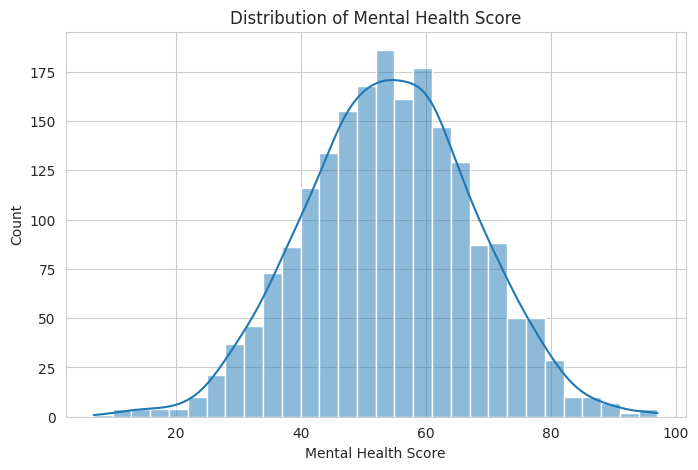

In [7]:
plt.figure(figsize=(8,5))
sns.histplot(df_clean[target], kde=True, bins=30)
plt.title('Distribution of Mental Health Score')
plt.xlabel('Mental Health Score')
plt.ylabel('Count')
plt.show()

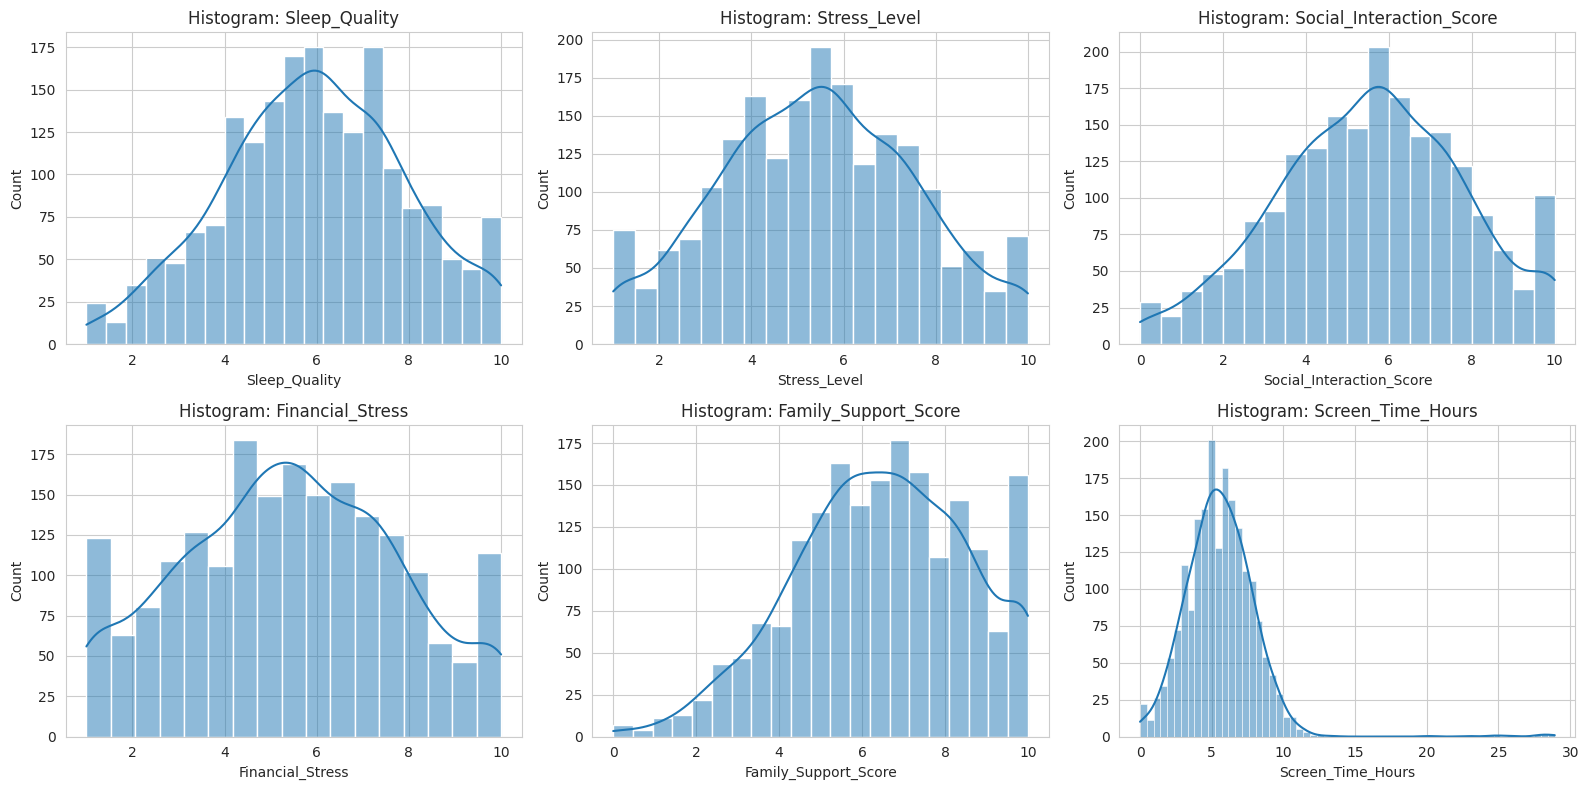

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
key_feats = ['Sleep_Quality', 'Stress_Level', 'Social_Interaction_Score',
             'Financial_Stress', 'Family_Support_Score', 'Screen_Time_Hours']
for ax, col in zip(axes.flat, key_feats):
    sns.histplot(df_clean[col].dropna(), kde=True, ax=ax)
    ax.set_title(f'Histogram: {col}')
plt.tight_layout()
plt.show()

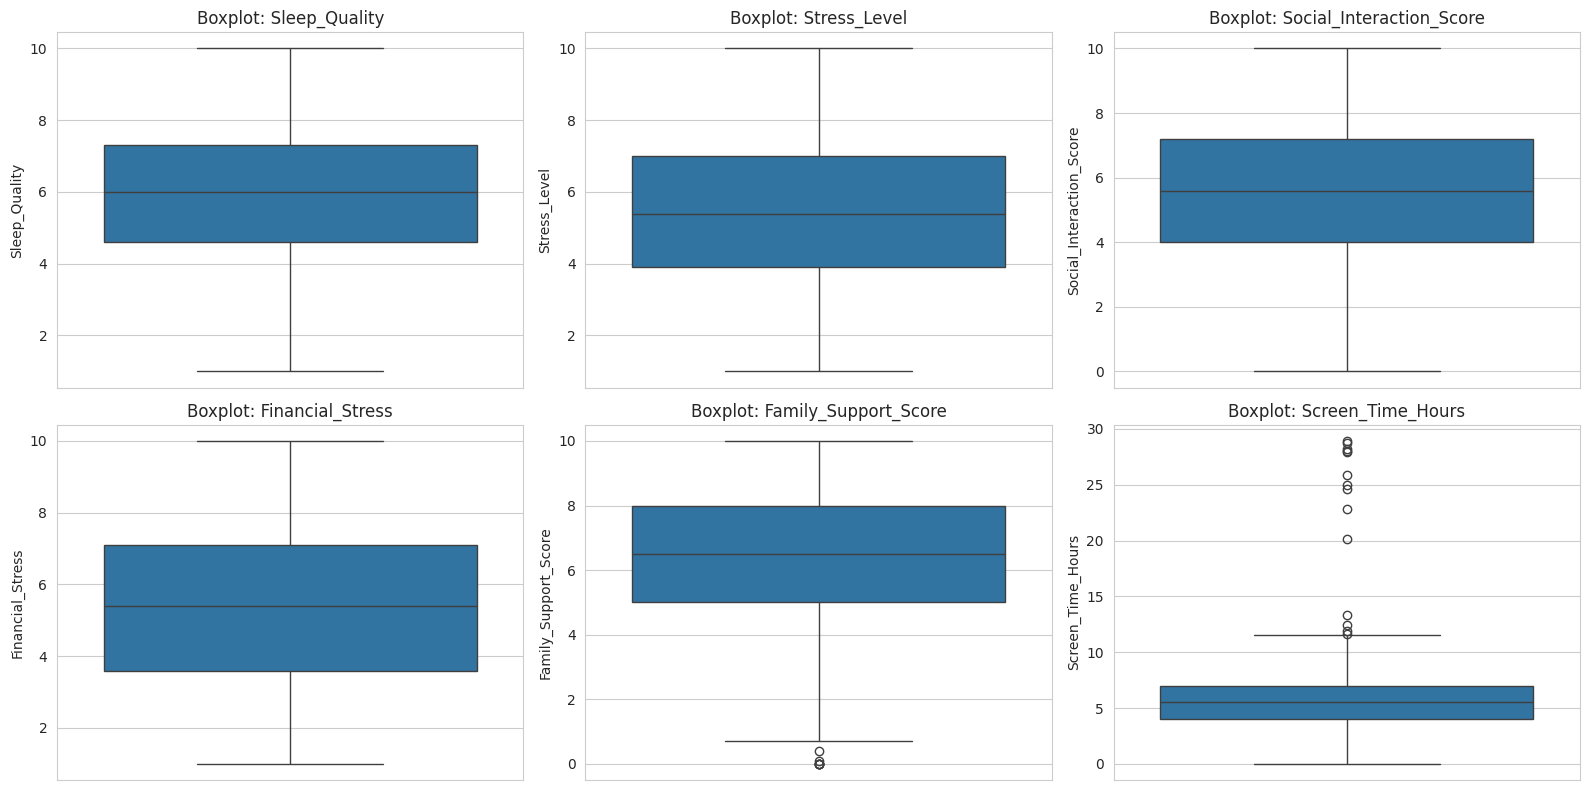

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flat, key_feats):
    sns.boxplot(y=df_clean[col], ax=ax)
    ax.set_title(f'Boxplot: {col}')
plt.tight_layout()
plt.show()

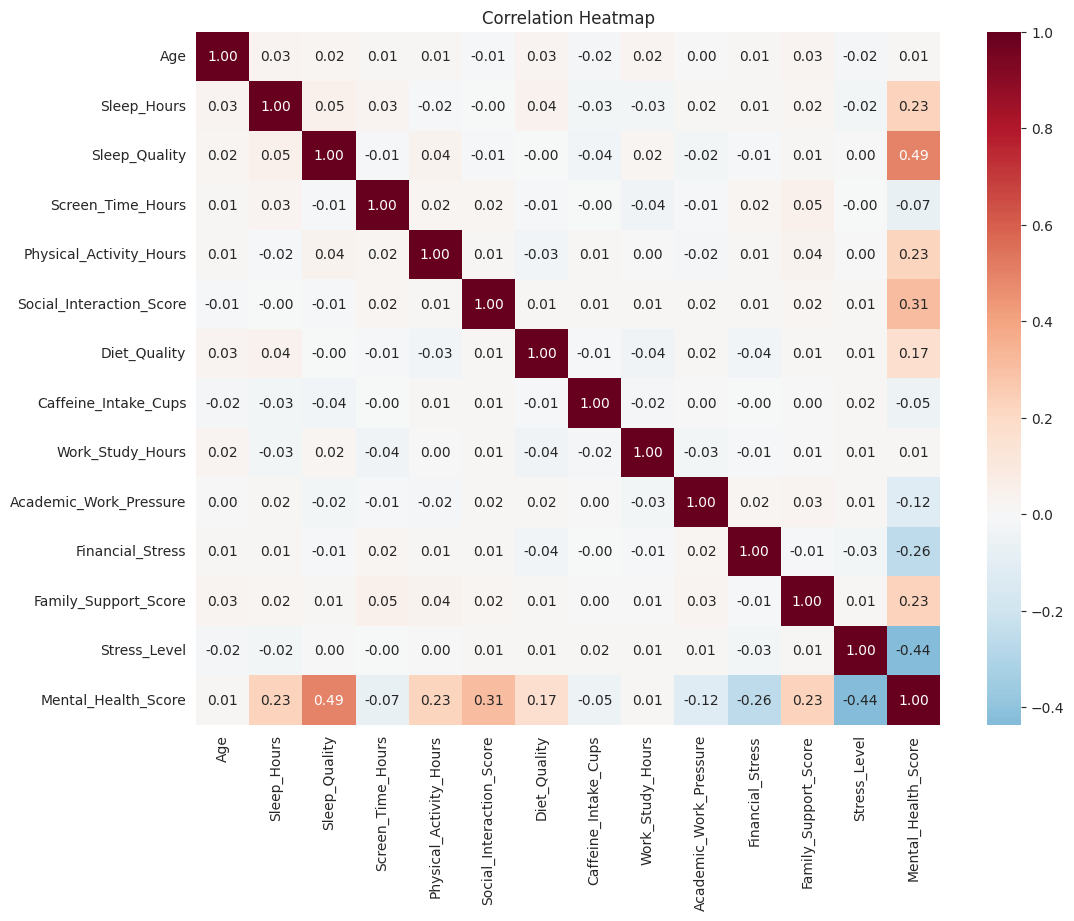

In [10]:
plt.figure(figsize=(12, 9))
corr = df_clean[num_cols + [target]].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0)
plt.title('Correlation Heatmap')
plt.show()

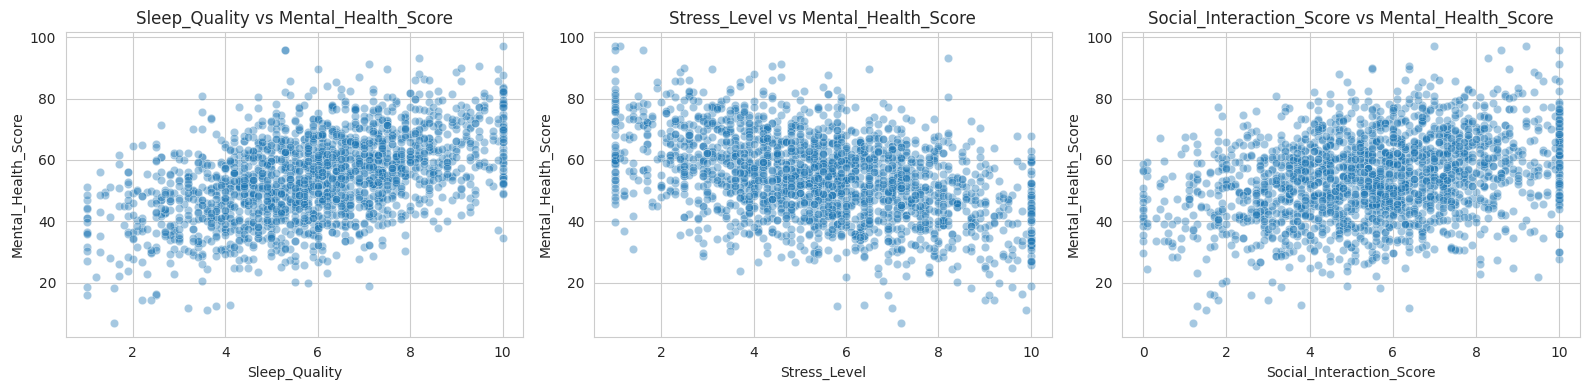

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ['Sleep_Quality', 'Stress_Level', 'Social_Interaction_Score']):
    sns.scatterplot(x=df_clean[col], y=df_clean[target], alpha=0.4, ax=ax)
    ax.set_title(f'{col} vs {target}')
plt.tight_layout()
plt.show()

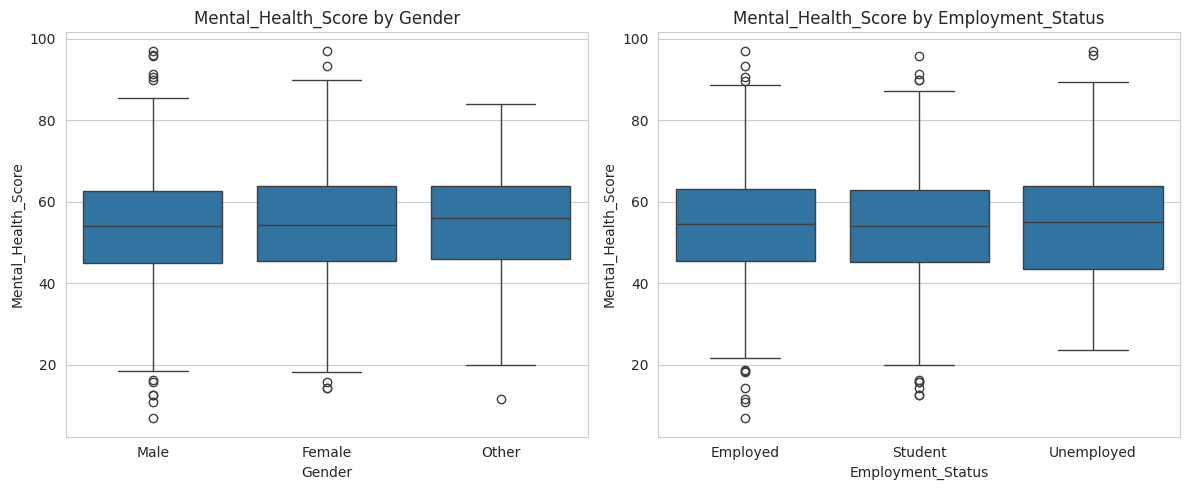

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, col in zip(axes, cat_cols):
    sns.boxplot(x=df_clean[col], y=df_clean[target], ax=ax)
    ax.set_title(f'{target} by {col}')
plt.tight_layout()
plt.show()

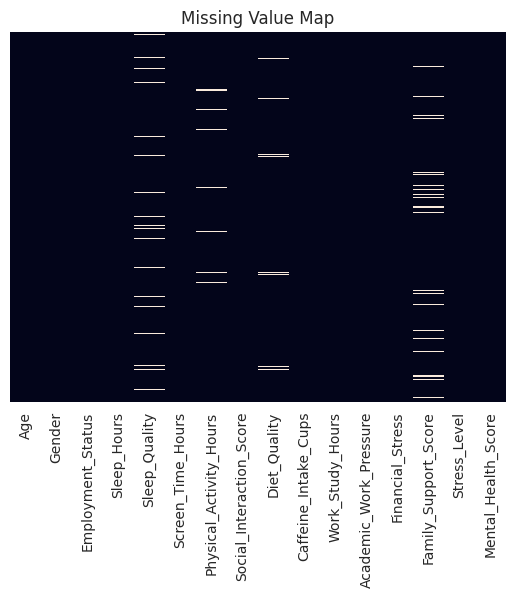

In [13]:
sns.heatmap(df_clean.isnull(), cbar=False, yticklabels=False)
plt.title('Missing Value Map')
plt.show()

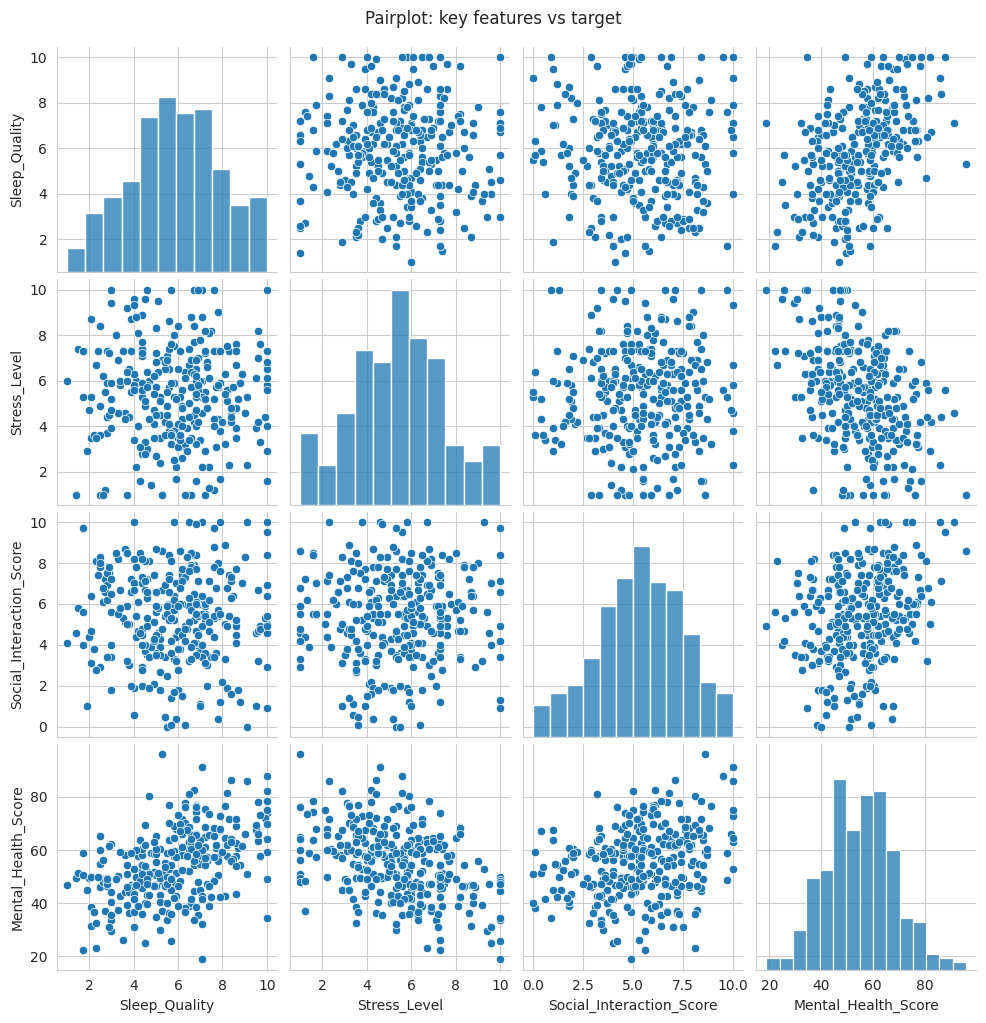

In [14]:
sample = df_clean[key_feats[:3] + [target]].sample(min(300, len(df_clean)), random_state=1)
sns.pairplot(sample)
plt.suptitle('Pairplot: key features vs target', y=1.02)
plt.show()

In [15]:
# Outlier counts via IQR
for col in num_cols:
    q1, q3 = df_clean[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
    n_out = ((df_clean[col] < lo) | (df_clean[col] > hi)).sum()
    if n_out:
        print(f'{col}: {n_out} outliers')

Sleep_Hours: 15 outliers
Screen_Time_Hours: 14 outliers
Physical_Activity_Hours: 90 outliers
Caffeine_Intake_Cups: 14 outliers
Work_Study_Hours: 4 outliers
Family_Support_Score: 7 outliers


## Step 4: Feature Engineering

- **Lifestyle_Score**: average of diet quality, capped physical activity, and an inverse screen-time penalty - a single summary of healthy daily habits.
- **Sleep_Efficiency_Score**: combines closeness-to-8-hours sleep duration with self-rated sleep quality.
- **Wellbeing_Support_Score**: average of social interaction and family support - a proxy for support-network strength.

In [16]:
from preprocessing import engineer_features, load_clean_data, build_preprocessor, TARGET
df_eng = engineer_features(df_clean)
df_eng[['Lifestyle_Score', 'Sleep_Efficiency_Score', 'Wellbeing_Support_Score']].describe()

,Lifestyle_Score,Sleep_Efficiency_Score,Wellbeing_Support_Score
count,1901.000000,1920.000000,1900.000000
mean,4.286042,6.620195,5.997079
std,1.203602,1.382170,1.552809
min,1.100000,1.600000,0.650000
25%,3.466667,5.650000,4.900000
50%,4.233333,6.700000,6.050000
75%,5.066667,7.625000,7.150000
max,8.366667,10.000000,10.000000


## Step 5-6: Model Training & Comparison

See `src/train.py` for the full training script (6 regression models, 5-fold cross-validation, GridSearchCV tuning, and feature importance). Run it with:

```bash
python3 src/train.py
```

Results are saved to `models/model.pkl` and `models/metrics.json`, and are loaded directly by `app.py` - the Streamlit dashboard never retrains from scratch.

In [17]:
import json
with open('../models/metrics.json') as f:
    metrics = json.load(f)
pd.DataFrame(metrics['baseline_comparison']).T.sort_values('R2', ascending=False)

,MAE,MSE,RMSE,R2,CV_R2_mean,CV_R2_std
Ridge Regression,5.261,44.536,6.674,0.7901,0.7566,0.0281
Linear Regression,5.262,44.551,6.675,0.7900,0.7565,0.0280
Gradient Boosting,5.723,52.062,7.215,0.7546,0.6971,0.0338
Lasso Regression,5.995,57.166,7.561,0.7305,0.7061,0.0342
Random Forest,6.297,66.011,8.125,0.6888,0.6563,0.0352
Decision Tree,8.446,113.724,10.664,0.4639,0.3754,0.0367


## Step 7: Explainability

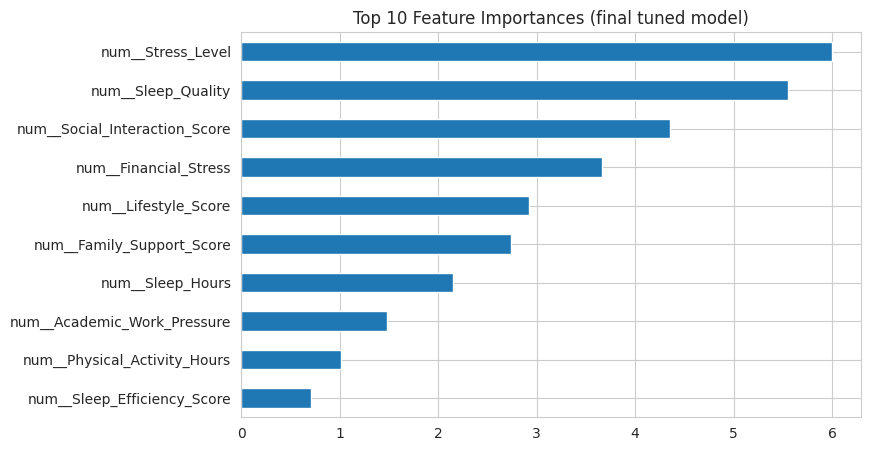

In [18]:
fi = pd.Series(metrics['feature_importance']).sort_values(ascending=False).head(10)
fi.plot(kind='barh', figsize=(8,5))
plt.title('Top 10 Feature Importances (final tuned model)')
plt.gca().invert_yaxis()
plt.show()

**Note:** feature importance shows how much the model relies on each input to produce its estimate. It does not indicate that any feature medically *causes* a mental health outcome.